<a href="https://colab.research.google.com/github/alaae2007/CST184/blob/main/Week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
     Country  %Renewable  CO2_per_capita   Region Apply_Policy
0      Nepal          88             1.2     Asia          yes
1      Kenya          65             1.8   Africa          yes
2    Germany          45             6.5   Europe           no
3      India          25             1.9     Asia          yes
4  Australia          35            17.0  Oceania           no

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         10 non-null     object 
 1   %Renewable      10 non-null     int64  
 2   CO2_per_capita  10 non-null     float64
 3   Region          10 non-null     object 
 4   Apply_Policy    10 non-null     object 
dtypes: float64(1), int64(1), object(3)
memory usage: 532.0+ bytes

Statistical summary:
       %Renewable  CO2_per_capita
count   10.000000       10.000000
mean    48.30

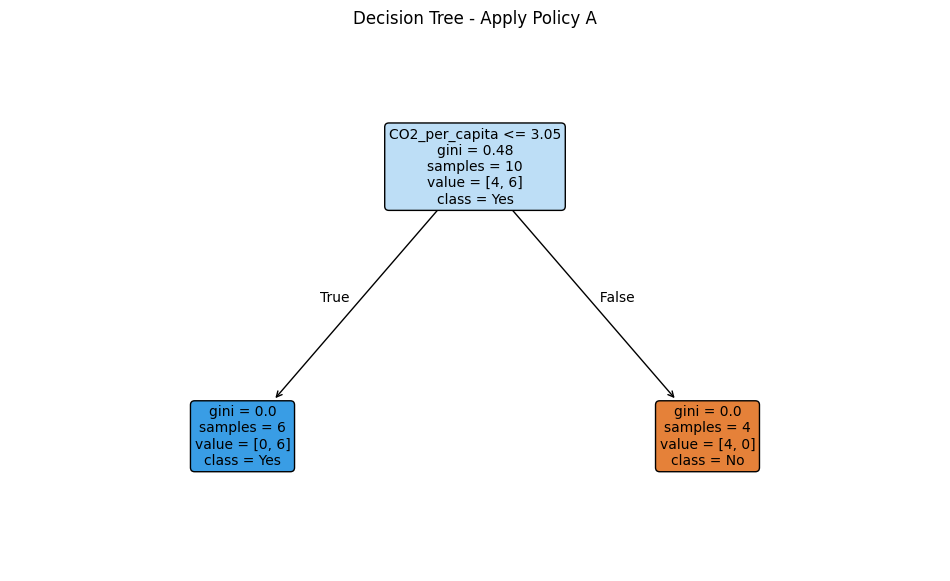


Decision Tree Interpretation:

The tree uses renewable energy percentage and CO2 emissions per capita
to decide whether Policy A should be applied.

The model looks for threshold values that best separate countries
labelled Yes from countries labelled No.

Countries with lower CO2 emissions are generally more likely to
receive a Yes classification in this dataset.

However, renewable energy percentage also contributes to the decision
rules produced by the model.

The dataset only contains 10 countries, so the decision tree should be
viewed as a demonstration rather than a model for real-world policy
decisions.


Predictions for new data:
   %Renewable  CO2_per_capita  Prediction Policy Decision
0          52             1.5           1             Yes
1          20             2.5           1             Yes
2          75             3.0           1             Yes

Additional prediction examples:
   %Renewable  CO2_per_capita  Prediction Policy Decision
0          90             1.0 

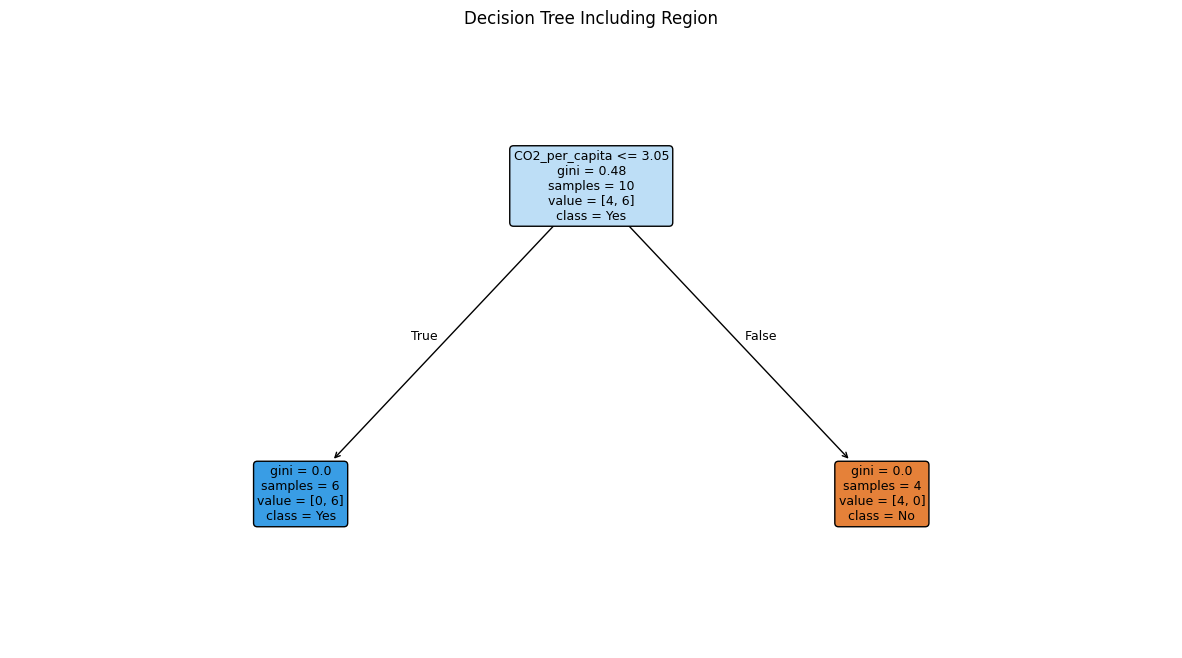


Prediction probabilities:
   %Renewable  CO2_per_capita  Probability No  Probability Yes
0          52             1.5             0.0              1.0
1          20             2.5             0.0              1.0
2          75             3.0             0.0              1.0

New policy based on CO2 < 1.5:
      Country  CO2_per_capita  New_Policy
0       Nepal             1.2           1
1       Kenya             1.8           0
2     Germany             6.5           0
3       India             1.9           0
4   Australia            17.0           0
5      Brazil             2.1           0
6     Nigeria             0.9           1
7      Sweden             4.0           0
8  Bangladesh             1.3           1
9         USA            15.5           0


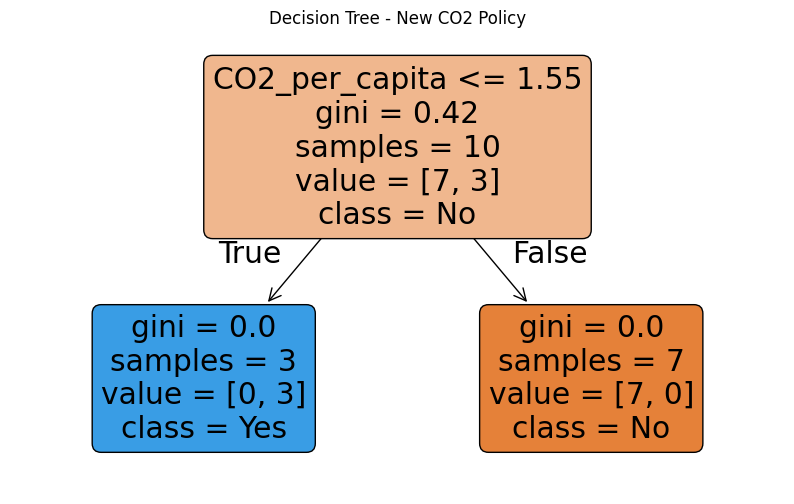


Reflection:

Changing the features or maximum tree depth changes the decision rules
that the model can create.

A smaller maximum depth produces a simpler model that is easier to
understand. Increasing the depth allows more detailed rules, although
this can also make the model more complex and increase the risk of
overfitting.

Adding Region gives the model another feature that it can potentially
use when making decisions. However, this dataset contains only 10
countries, so there is not enough data to make strong conclusions
about differences between regions.

The original data also suggests that CO2 emissions are important for
Policy A. Countries with relatively low CO2 emissions such as Nepal,
Kenya, India, Nigeria and Bangladesh are labelled Yes, while countries
with much higher emissions such as Germany, Australia and the USA are
labelled No.

An interesting example is Sweden. Sweden has the highest renewable
energy percentage in the dataset at 95%, but it is still labelled No
be

In [2]:
# CST184 Week 3
# Logical Reasoning & Decision Trees
# Classifying Countries Using Decision Trees

import pandas as pd
import matplotlib.pyplot as plt

# Step 2: Load the dataset

df = pd.read_csv("week3_policy_data.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
print(df.describe())


# Step 3: Encode the target label

df["Label"] = df["Apply_Policy"].map({
    "yes": 1,
    "no": 0
})

print("\nPolicy labels:")
print(df[["Country", "Apply_Policy", "Label"]])

print("""
The Apply_Policy column originally contains text values of yes and no.

These have been converted into numerical labels so that the decision
tree can use them:

yes = 1
no = 0
""")


# Step 4: Define the features and train the decision tree

from sklearn.tree import DecisionTreeClassifier

X = df[["%Renewable", "CO2_per_capita"]]
y = df["Label"]

tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=0
)

tree.fit(X, y)

print("\nDecision tree trained successfully.")
print("Features used:")
print(list(X.columns))


# Try This: Compare different tree depths

tree_depth_2 = DecisionTreeClassifier(
    max_depth=2,
    random_state=0
)

tree_depth_2.fit(X, y)

tree_depth_4 = DecisionTreeClassifier(
    max_depth=4,
    random_state=0
)

tree_depth_4.fit(X, y)

print("\nTree depth comparison:")
print("Depth 2 actual depth:", tree_depth_2.get_depth())
print("Depth 3 actual depth:", tree.get_depth())
print("Depth 4 actual depth:", tree_depth_4.get_depth())

print("""
Changing max_depth controls how complex the decision tree is allowed
to become.

A smaller depth creates a simpler tree with fewer decisions.

A larger depth allows the model to create more decision rules, which
can fit the training data more closely but may increase the risk of
overfitting.
""")


# Step 5: Visualise the decision tree

from sklearn.tree import plot_tree

plt.figure(figsize=(12, 7))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree - Apply Policy A")
plt.show()


# Explain the decision tree

print("""
Decision Tree Interpretation:

The tree uses renewable energy percentage and CO2 emissions per capita
to decide whether Policy A should be applied.

The model looks for threshold values that best separate countries
labelled Yes from countries labelled No.

Countries with lower CO2 emissions are generally more likely to
receive a Yes classification in this dataset.

However, renewable energy percentage also contributes to the decision
rules produced by the model.

The dataset only contains 10 countries, so the decision tree should be
viewed as a demonstration rather than a model for real-world policy
decisions.
""")


# Step 6: Make predictions

new_data = pd.DataFrame({
    "%Renewable": [52, 20, 75],
    "CO2_per_capita": [1.5, 2.5, 3.0]
})

predictions = tree.predict(new_data)

prediction_results = new_data.copy()
prediction_results["Prediction"] = predictions
prediction_results["Policy Decision"] = prediction_results["Prediction"].map({
    1: "Yes",
    0: "No"
})

print("\nPredictions for new data:")
print(prediction_results)


# Try This: Add some additional countries/scenarios

extra_data = pd.DataFrame({
    "%Renewable": [90, 30, 60, 15],
    "CO2_per_capita": [1.0, 10.0, 2.0, 16.0]
})

extra_predictions = tree.predict(extra_data)

extra_results = extra_data.copy()
extra_results["Prediction"] = extra_predictions
extra_results["Policy Decision"] = extra_results["Prediction"].map({
    1: "Yes",
    0: "No"
})

print("\nAdditional prediction examples:")
print(extra_results)


# Challenge 1: Add Region as a third feature

region_encoded = pd.get_dummies(
    df["Region"],
    prefix="Region"
)

X_region = pd.concat(
    [
        df[["%Renewable", "CO2_per_capita"]],
        region_encoded
    ],
    axis=1
)

tree_with_region = DecisionTreeClassifier(
    max_depth=3,
    random_state=0
)

tree_with_region.fit(X_region, y)

print("\nFeatures after encoding Region:")
print(list(X_region.columns))


# Visualise the tree with Region included

plt.figure(figsize=(15, 8))

plot_tree(
    tree_with_region,
    feature_names=X_region.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Including Region")
plt.show()


# Challenge 2: Predict probabilities

probabilities = tree.predict_proba(new_data)

probability_results = new_data.copy()
probability_results["Probability No"] = probabilities[:, 0]
probability_results["Probability Yes"] = probabilities[:, 1]

print("\nPrediction probabilities:")
print(probability_results)


# Challenge 3: Create a new policy label
# New policy rule: CO2 emissions below 1.5 tonnes

df["New_Policy"] = (
    df["CO2_per_capita"] < 1.5
).astype(int)

print("\nNew policy based on CO2 < 1.5:")
print(
    df[
        [
            "Country",
            "CO2_per_capita",
            "New_Policy"
        ]
    ]
)


# Train a decision tree for the new policy

X_new = df[["%Renewable", "CO2_per_capita"]]
y_new = df["New_Policy"]

new_policy_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=0
)

new_policy_tree.fit(X_new, y_new)

plt.figure(figsize=(10, 6))

plot_tree(
    new_policy_tree,
    feature_names=X_new.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree - New CO2 Policy")
plt.show()


# Reflection

print("""
Reflection:

Changing the features or maximum tree depth changes the decision rules
that the model can create.

A smaller maximum depth produces a simpler model that is easier to
understand. Increasing the depth allows more detailed rules, although
this can also make the model more complex and increase the risk of
overfitting.

Adding Region gives the model another feature that it can potentially
use when making decisions. However, this dataset contains only 10
countries, so there is not enough data to make strong conclusions
about differences between regions.

The original data also suggests that CO2 emissions are important for
Policy A. Countries with relatively low CO2 emissions such as Nepal,
Kenya, India, Nigeria and Bangladesh are labelled Yes, while countries
with much higher emissions such as Germany, Australia and the USA are
labelled No.

An interesting example is Sweden. Sweden has the highest renewable
energy percentage in the dataset at 95%, but it is still labelled No
because its CO2 emissions are higher than those of many countries
labelled Yes.

This demonstrates why decision trees can be useful. Instead of making
a decision using only one factor, the model can consider multiple
features and create logical rules from the available data.

For real sustainability policy decisions, a much larger dataset and
additional social, economic and environmental variables would be
needed.
""")